<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/python/project02/'
else:
    path = ''

Mounted at /content/drive


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [3]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [4]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [5]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [6]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [7]:
new_test.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,27204,12710,Female,Loyal Customer,33.0,Business Travel,Business,3613,2.0,3,...,2,2,2,2,4,2,2,0,1.0,Neutral or Dissatisfied
1,102914,26571,Male,Loyal Customer,57.0,Personal Travel,Business,406,2.0,3,...,1,1,2,4,4,1,1,0,0.0,Neutral or Dissatisfied
2,40657,89137,Male,Loyal Customer,66.0,Business Travel,Eco,1919,2.0,3,...,2,3,2,4,4,4,2,17,7.0,Neutral or Dissatisfied
3,15726,122043,Female,Loyal Customer,56.0,Business Travel,Business,2984,4.0,4,...,5,5,5,4,4,5,4,0,0.0,Satisfied
4,26283,37613,Male,Loyal Customer,27.0,Personal Travel,Eco,944,2.0,3,...,2,1,4,3,2,3,2,29,17.0,Neutral or Dissatisfied


In [8]:
# 함수 만들기
def build_model_input(data):

    # 원본 DataFrame 변경을 피하기 위해 복사본을 만듭니다.
    data = data.copy()

    # 1. 결측치 처리
    num_cols = data.select_dtypes(include=['number']).columns # 수치형 변수 선택

    # 결측치 → 중앙값
    for col in num_cols:
      median_val = data[col].median()
      data[col].fillna(median_val, inplace=True)

    cat_cols = data.select_dtypes(include=['object', 'category']).columns # 범주형 변수 선택

    # 결측치 → 최빈값
    for col in cat_cols:
      mode_v = data[col].mode() # mode()는 Series를 반환합니다.
      if not mode_v.empty:
          data[col].fillna(mode_v[0], inplace=True) # mode_v[0]를 사용하여 실제 최빈값을 채웁니다.

    # 2. 값 변경

    # Target -> Satisfaction 값을 1과 0으로
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

    # 3. 변수 제거
    data.drop(columns=['Unnamed: 0', 'ID'], axis=1, inplace=True)

    # 4. 라벨 인코딩
    # 문자열 변수 리스트로 선언
    cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

    # 라벨 인코딩
    for col in cat_cols:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col])

    # 5. 가변수화

    categories = [0, 1, 2, 3, 4, 5] # 설문 범주 정의

    # 가변수화 대상 변수
    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
                'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
                'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

    # Category 형 변수로 변환
    for col in dumm_cols:
        data[col] = pd.Categorical(data[col], categories=categories)

    # 가변수화
    data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

    # 6. x, y 분리
    target = 'Satisfaction'
    x = data.drop(target, axis=1)
    y = data.loc[:, target]

    # 7. 스케일링
    x = scaler.transform(x)# 불러온 scaler(글로벌 변수)를 사용하여 transform만 수행

    # 반환
    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [9]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


### 데이터 확인하기

In [10]:
# x_val, y_val 타입 확인
print(f"x_val의 타입: {type(x_val)}")
print(f"x_val 내부 요소의 타입: {x_val.dtype}")
print("-" * 30)
print(f"y_val의 타입: {type(y_val)}")
print(f"y_val 내부 요소의 타입: {y_val.dtype}")

x_val의 타입: <class 'numpy.ndarray'>
x_val 내부 요소의 타입: float64
------------------------------
y_val의 타입: <class 'pandas.core.series.Series'>
y_val 내부 요소의 타입: int64


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [11]:
x_val, y_val = build_model_input(new_test)

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [12]:
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


In [13]:
print(classification_report(y_pred, y_val))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       178
           1       0.97      0.90      0.94       172

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



In [14]:
print(confusion_matrix(y_pred, y_val))

[[174   4]
 [ 17 155]]


## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [15]:
x_train, y_train = build_model_input(new_train)

- 클래스 불균형이 존재하는지 확인합니다.

In [16]:
print('y_train 클래스 분포:')
print(y_train.value_counts())

print('\n[비율]')
print(y_train.value_counts(normalize=True))

y_train 클래스 분포:
Satisfaction
0    463
1    387
Name: count, dtype: int64

[비율]
Satisfaction
0    0.544706
1    0.455294
Name: proportion, dtype: float64


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [17]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,445 (240.02 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,964 (160.02 KB)

In [18]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
retraining_model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 모델 요약
retraining_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,481 (80.00 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [19]:
# 학습 설정
retraining_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

In [20]:
# 1. 클래스 가중치 설정 (불만족 0번에 10배 중요도 부여)
#class_weights = {0: 10.0, 1: 1.0}
# 이번 데이터에서는 0과 1의 클래스가 55:45 의 비율로 존재하기 때문에 가중치가 필요 없다고 판단함.

# 2. 모델 학습 (검증 데이터와 가중치 통합)
hist = retraining_model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=64,              # 곡선을 매끄럽게 하기 위해 64
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 #class_weight=class_weights,
                 callbacks=[es],
                 verbose=1)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - accuracy: 0.5471 - loss: 0.6935 - val_accuracy: 0.6057 - val_loss: 0.6576
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5918 - loss: 0.6581 - val_accuracy: 0.7343 - val_loss: 0.6275
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6753 - loss: 0.6169 - val_accuracy: 0.8057 - val_loss: 0.5939
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6988 - loss: 0.5904 - val_accuracy: 0.8000 - val_loss: 0.5490
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7494 - loss: 0.5447 - val_accuracy: 0.8086 - val_loss: 0.4985
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7859 - loss: 0.4891 - val_accuracy: 0.8114 - val_loss: 0.4500
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8165 - loss: 0.4430 - val_accuracy: 0.8486 - val_loss: 0.4074
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8565 - loss: 0.4038 - val_accuracy: 0.8514 - val_lo

- 학습 곡선을 확인합니다.

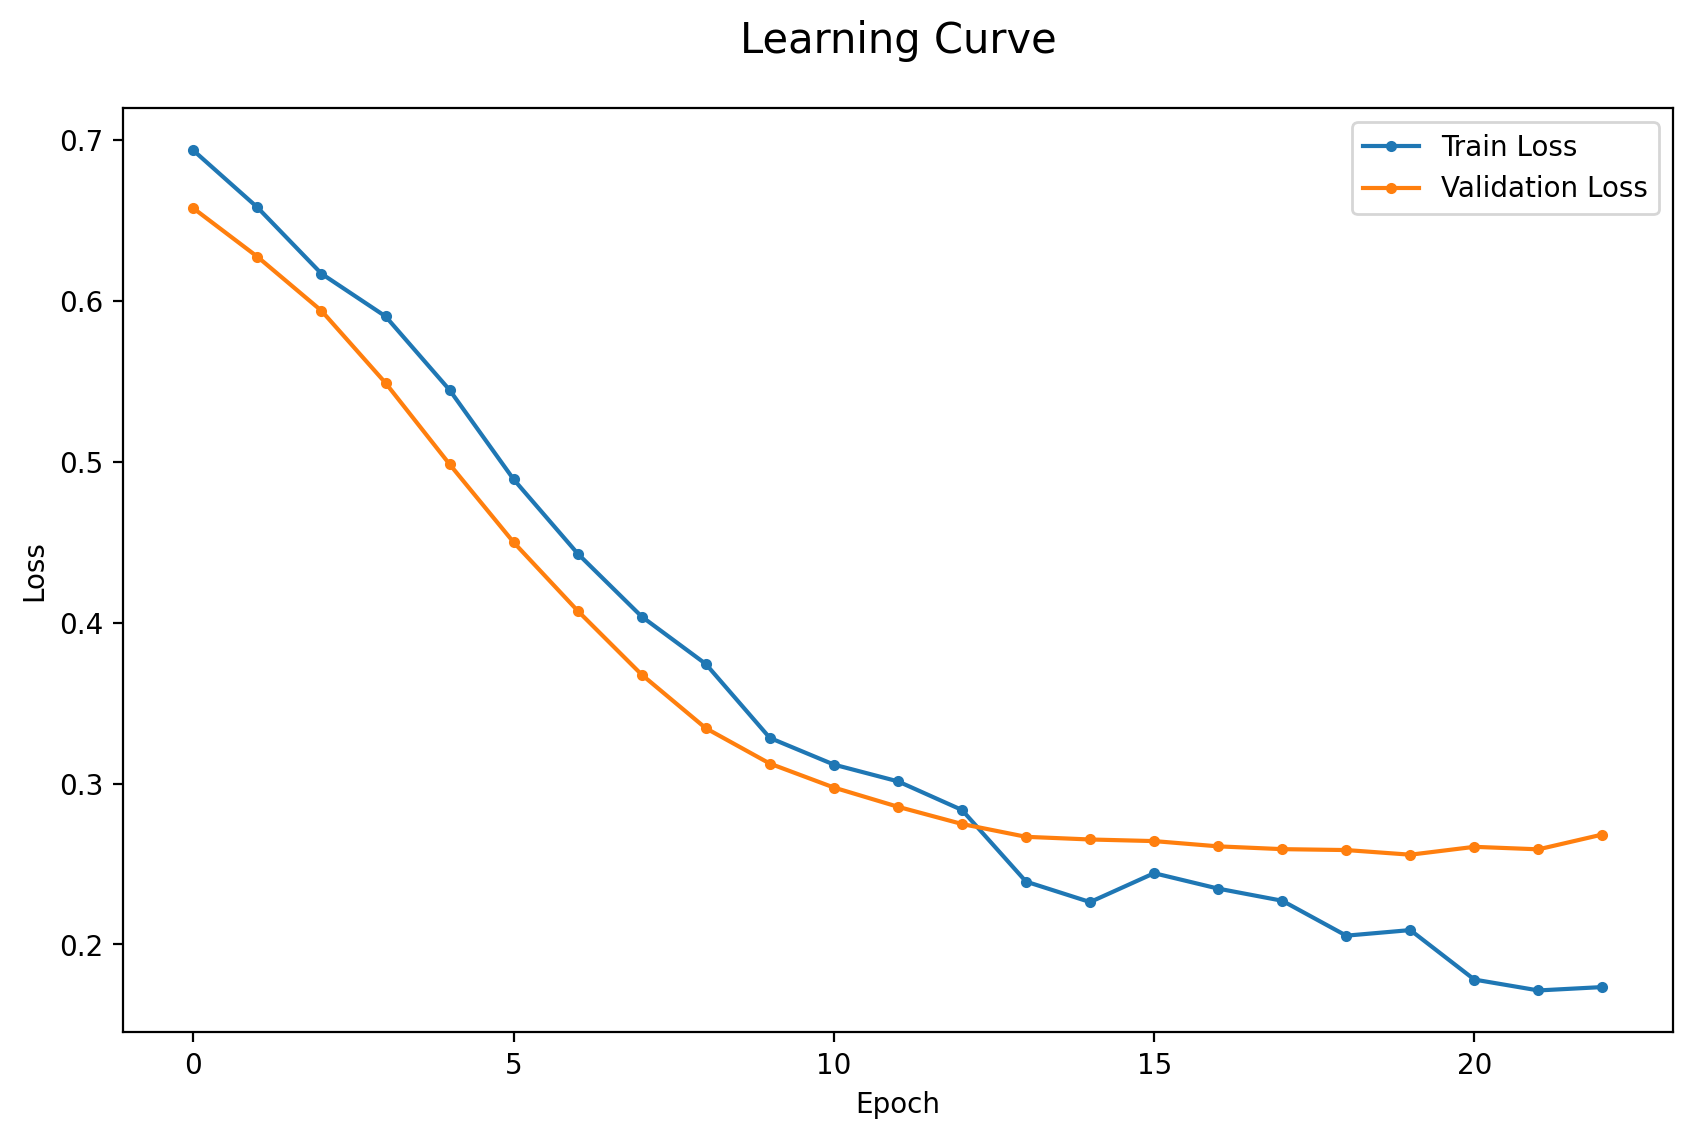

In [21]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [22]:
y_pred = retraining_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [23]:
print(classification_report(y_pred, y_val))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       192
           1       0.89      0.89      0.89       158

    accuracy                           0.90       350
   macro avg       0.90      0.90      0.90       350
weighted avg       0.90      0.90      0.90       350



In [24]:
print(confusion_matrix(y_pred, y_val))

[[174  18]
 [ 17 141]]


### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [25]:
# 기존에 불러온 base_model을 그대로 사용합니다.
continual_model = base_model

#### 실험1. 클래스 불균형 가중치를 뺀 원래 학습하던 파라미터와 설정으로 진행

- 학습 방법을 설정하고 학습을 수행합니다.

In [26]:
# 학습 설정
continual_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

In [27]:
# 모델 학습
hist = continual_model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=64,
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 callbacks=[es],
                 verbose=1)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.9459 - loss: 0.2089 - val_accuracy: 0.9486 - val_loss: 0.2429
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9482 - loss: 0.1432 - val_accuracy: 0.9400 - val_loss: 0.2288
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9624 - loss: 0.1106 - val_accuracy: 0.9429 - val_loss: 0.2272
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9659 - loss: 0.0932 - val_accuracy: 0.9371 - val_loss: 0.2311
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9682 - loss: 0.0933 - val_accuracy: 0.9371 - val_loss: 0.2340
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9706 - loss: 0.0829 - val_accuracy: 0.9400 - val_loss: 0.2381
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9753 - loss: 0.0720 - val_accuracy: 0.9371 - val_loss: 0.2401
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9776 - loss: 0.0700 - val_accuracy: 0.9371 - val_los

- 학습 곡선을 확인합니다.

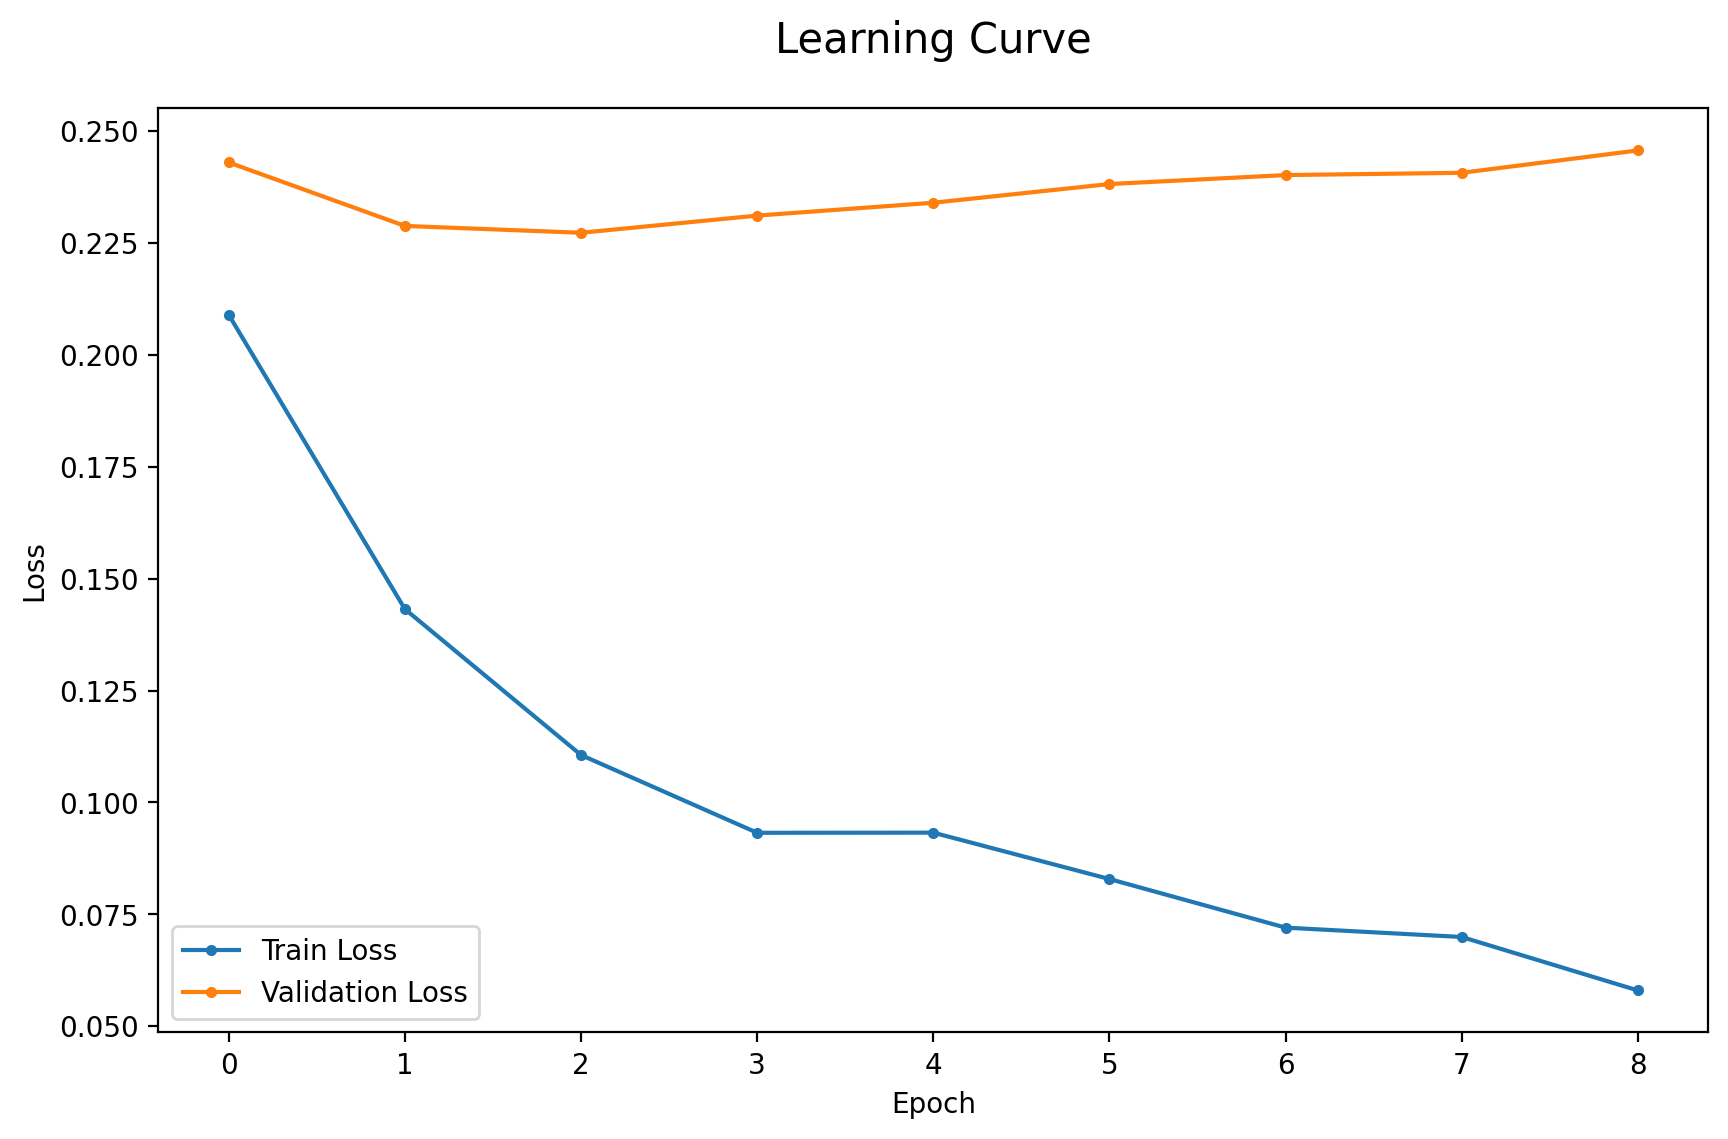

In [28]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [29]:
y_pred = continual_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [30]:
print(classification_report(y_pred, y_val))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       190
           1       0.94      0.93      0.93       160

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



In [31]:
print(confusion_matrix(y_pred, y_val))

[[180  10]
 [ 11 149]]


#### 실험2. 다른 방법을 도입하여 진행

In [32]:
# 기존에 불러온 base_model을 그대로 사용합니다.
continual_model2 = base_model

- 학습 방법을 설정하고 학습을 수행합니다.

In [33]:
# 학습 설정
continual_model2.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

In [34]:
# 모델 학습
hist = continual_model2.fit(x_train, y_train,
                 epochs=20,
                 batch_size=16,
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 callbacks=[es],
                 verbose=1)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9576 - loss: 0.1300 - val_accuracy: 0.9429 - val_loss: 0.2426
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9659 - loss: 0.1105 - val_accuracy: 0.9371 - val_loss: 0.2465
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9647 - loss: 0.0977 - val_accuracy: 0.9343 - val_loss: 0.2542
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.0832 - val_accuracy: 0.9371 - val_loss: 0.2539
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9788 - loss: 0.0683 - val_accuracy: 0.9343 - val_loss: 0.2524
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9753 - loss: 0.0607 - val_accuracy: 0.9314 - val_loss: 0.2594
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.0661 - val_accuracy: 0.9314 - val_loss: 0.2578
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9859 - loss: 0.0408 - val_accuracy: 0.9314 - val_loss

- 학습 곡선을 확인합니다.

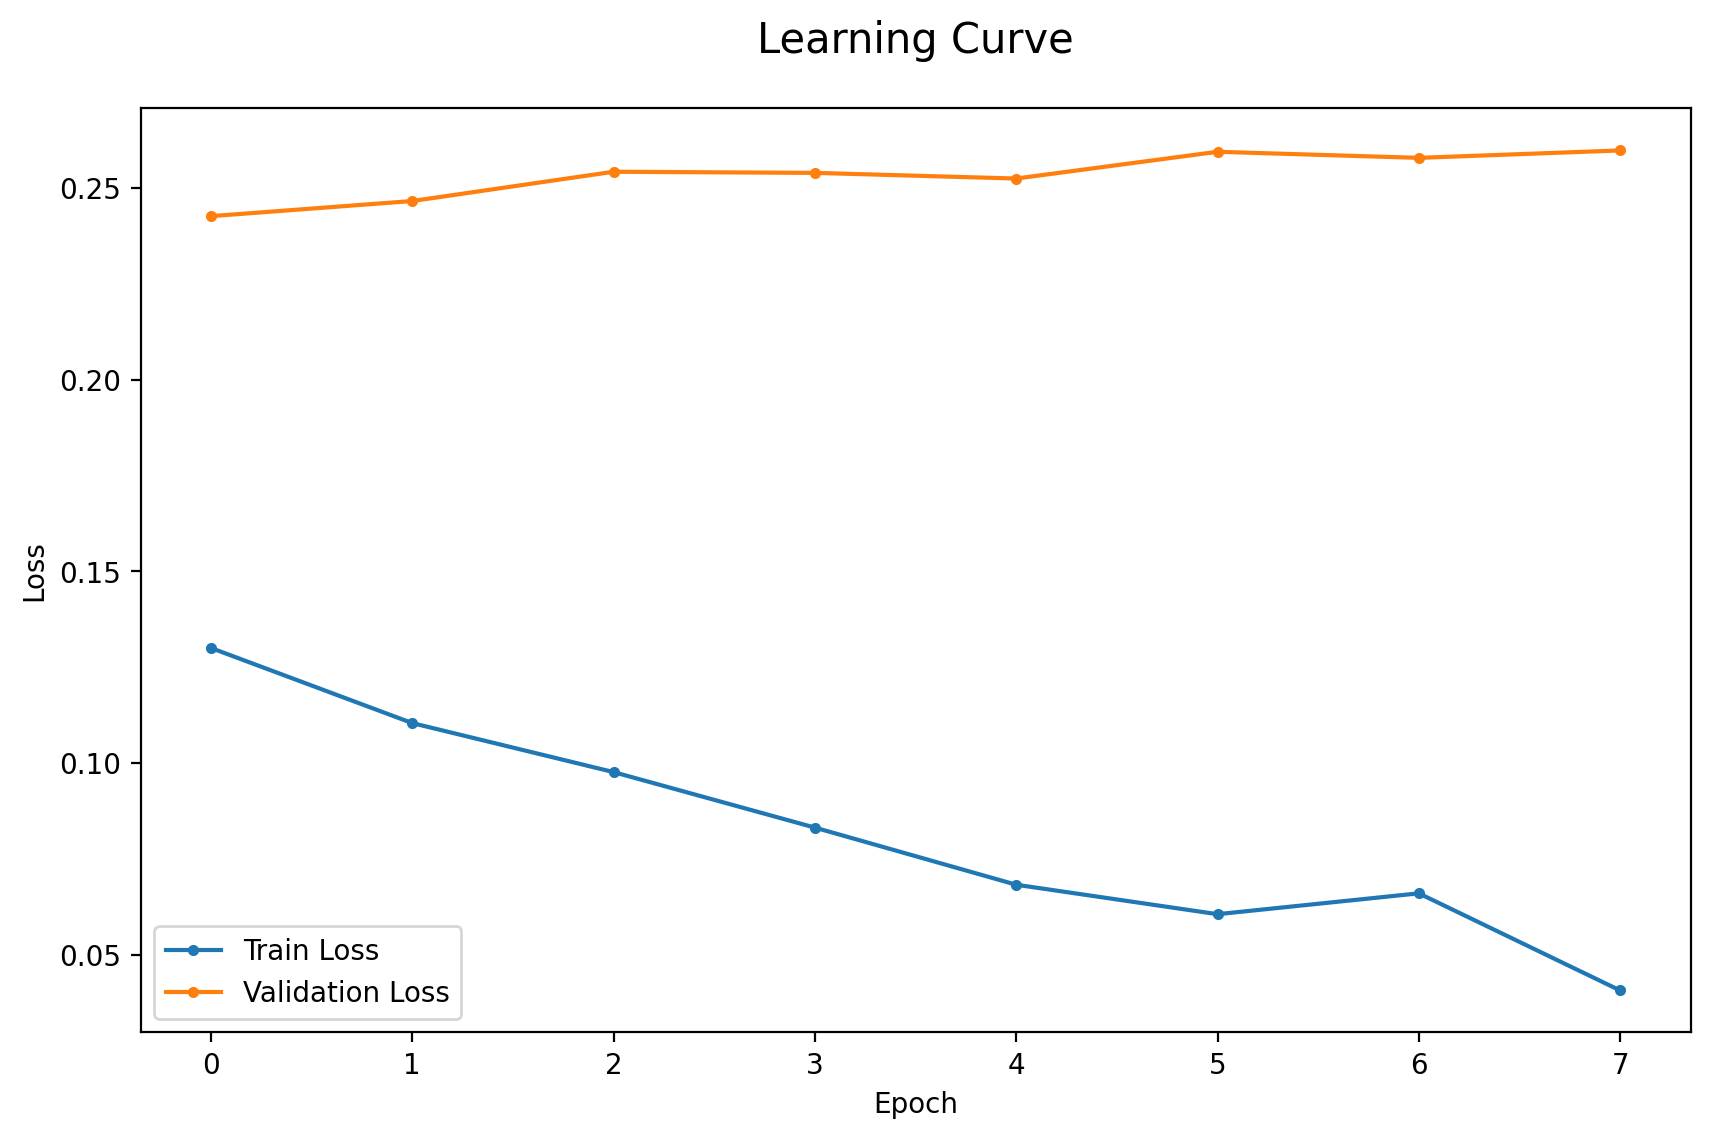

In [35]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [36]:
y_pred = continual_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [37]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       191
           1       0.95      0.92      0.94       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



In [38]:
print(confusion_matrix(y_val, y_pred))

[[183   8]
 [ 12 147]]


### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [39]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_3, built=True>

In [40]:
for layer in base_model.layer[:-1]:
  layer.trainable = False

continual_model = Sequential([
    base_model,
    Dense(1, activation='sigmoid')
])

AttributeError: 'Sequential' object has no attribute 'layer'

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 학습 설정
continual_model2.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

- 학습 곡선을 확인합니다.

In [ ]:
# 모델 학습
hist = continual_model2.fit(x_train, y_train,
                 epochs=20,
                 batch_size=16,
                 validation_data=(x_val, y_val), # 분리해둔 검증셋 사용
                 callbacks=[es],
                 verbose=1)

- 검증 데이터로 예측 및 평가를 수행합니다.